# Первичный анализ и подготовка данных

В этом ноутбуке проводится первичный анализ датасета перед обучением моделей. Работа выполняется по шагам: сначала описывается источник данных, затем проверяются размер датасета, типы признаков, пропуски и дубликаты. После этого анализируются распределения, выбросы и связи признаков с целевой переменной.

В конце формируется очищенная версия данных и выполняется разбиение на train, validation и test. Это позволяет дальше обучать модели на единой подготовленной выборке и снижает риск утечки данных.


## Источник данных

Используется датасет [Cardiovascular Disease Dataset](https://www.kaggle.com/datasets/sulianova/cardiovascular-disease-dataset) с Kaggle. Датасет выбран, потому что задача хорошо интерпретируется: по характеристикам пациента нужно предсказать наличие сердечно-сосудистого заболевания.

В данных есть признаки, которые имеют понятный физический или медицинский смысл: возраст, рост, вес, артериальное давление, уровень холестерина, уровень глюкозы, привычки и физическая активность. Это удобно для первичного анализа, так как для части признаков можно определить реалистичные диапазоны и обнаружить явные ошибки в данных.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.preprocessing import (
    CLEANING_LIMITS,
    RANDOM_STATE,
    clean_data,
    load_raw_data,
    make_train_val_test_split,
    save_processed_data,
    split_features_target,
)

sns.set_theme(style="whitegrid", palette="Set2")

RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "cardio_train.csv"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cardio_clean.csv"
FIGURES_DIR = PROJECT_ROOT / "report" / "images"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE


42

## Загрузка данных

На первом шаге загружается исходный файл `cardio_train.csv` из папки `data/raw`. После загрузки выводятся первые строки, чтобы проверить структуру таблицы, названия колонок и общий вид значений.


In [2]:
df_raw = load_raw_data(RAW_DATA_PATH)
df_raw.head()


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


## Первичная проверка структуры

Далее проверяются базовые характеристики датасета: количество строк и столбцов, число полных дубликатов, наличие пропусков, типы данных и количество уникальных значений в колонках.


In [3]:
dataset_summary = pd.DataFrame(
    {
        "rows": [df_raw.shape[0]],
        "columns": [df_raw.shape[1]],
        "duplicates": [df_raw.duplicated().sum()],
        "missing_values": [df_raw.isna().sum().sum()],
    }
)

dataset_summary


,rows,columns,duplicates,missing_values
0,70000,13,0,0


In [4]:
columns_summary = pd.DataFrame(
    {
        "dtype": df_raw.dtypes,
        "missing": df_raw.isna().sum(),
        "unique": df_raw.nunique(),
    }
)

columns_summary


,dtype,missing,unique
id,int64,0,70000
age,int64,0,8076
gender,int64,0,2
height,int64,0,109
weight,float64,0,287
ap_hi,int64,0,153
ap_lo,int64,0,157
cholesterol,int64,0,3
gluc,int64,0,3
smoke,int64,0,2


По результатам первичной проверки в датасете 70 000 строк и 13 столбцов. Явных пропусков и полных дубликатов нет, поэтому основной акцент при очистке будет сделан не на заполнении пропусков, а на проверке типов данных, допустимых значений и выбросов.

Отдельно важно учитывать, что некоторые признаки закодированы числами, но по смыслу являются категориальными: `gender`, `cholesterol`, `gluc`, `smoke`, `alco`, `active` и целевая переменная `cardio`.


## Распределения числовых признаков до очистки

Перед очисткой данных проанализируем не только общие характеристики датасета, но и распределения числовых признаков. Это позволит выявить значения, которые заметно отличаются от основной массы наблюдений, и затем корректно их отфильтровать.

Основное внимание уделим росту, весу и артериальному давлению, так как эти признаки могут быть важны для дальнейшего обучения моделей, а для их значений можно определить понятные реалистичные диапазоны.


In [5]:
raw_numeric = df_raw.assign(age_years=df_raw["age"] / 365.25)
raw_numeric_columns = ["age_years", "height", "weight", "ap_hi", "ap_lo"]

raw_numeric[raw_numeric_columns].describe(
    percentiles=[0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]
).T.round(2)


,count,mean,std,min,0.1%,1%,5%,25%,50%,75%,95%,99%,99.9%,max
age_years,70000.0,53.30,6.75,29.56,39.23,39.61,41.26,48.36,53.94,58.39,63.68,64.31,64.68,64.92
height,70000.0,164.36,8.21,55.00,120.00,147.00,152.00,159.00,165.00,170.00,178.00,184.00,190.00,250.00
weight,70000.0,74.21,14.40,10.00,40.00,48.00,55.00,65.00,72.00,82.00,100.00,117.00,150.00,200.00
ap_hi,70000.0,128.82,154.01,-150.00,12.00,90.00,100.00,120.00,120.00,140.00,160.00,180.00,220.00,16020.00
ap_lo,70000.0,96.63,188.47,-70.00,40.00,60.00,70.00,80.00,80.00,90.00,100.00,1000.00,1110.00,11000.00


По описательным статистикам видно, что основная часть значений находится в правдоподобных диапазонах, но в отдельных строках есть явные аномалии. Например, медианный рост составляет около 165 см, а 99% значений не превышают 184 см, при этом минимум равен 55 см, а максимум — 250 см.

Для давления отклонения выражены сильнее: встречаются отрицательные значения и значения на несколько порядков выше реалистичных медицинских измерений. Поэтому дополнительно построим графики по полному диапазону значений, чтобы увидеть влияние экстремальных выбросов на распределения.


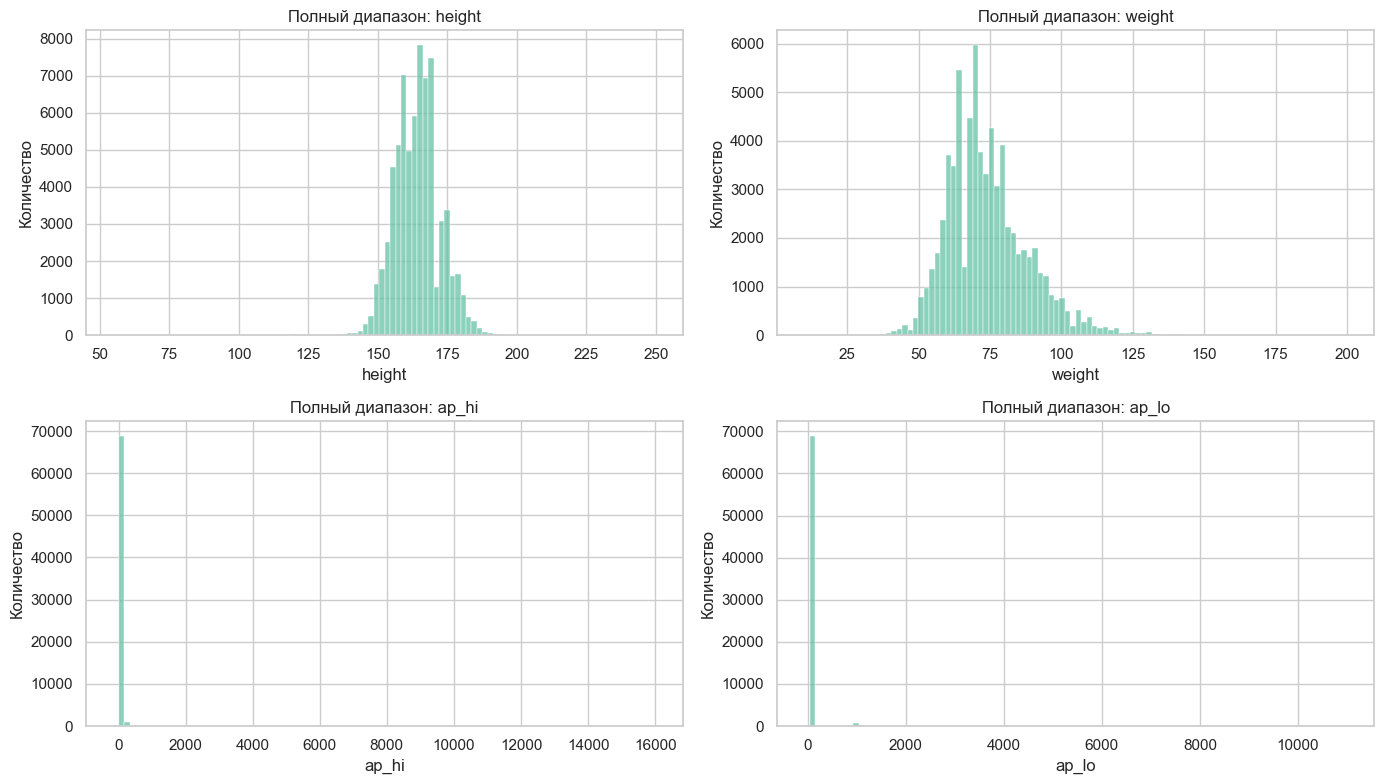

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, column in zip(axes.ravel(), ["height", "weight", "ap_hi", "ap_lo"]):
    sns.histplot(df_raw[column], bins=100, ax=ax)
    ax.set_title(f"Полный диапазон: {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Количество")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "raw_numeric_distributions_full_range.png", dpi=150)
plt.show()


По графикам видно, что в данных есть отдельные сильные выбросы, которые заметно растягивают шкалу, особенно для признаков давления. Из-за этого основная часть значений отображается менее подробно, поэтому дополнительно построим графики в более реалистичных диапазонах.

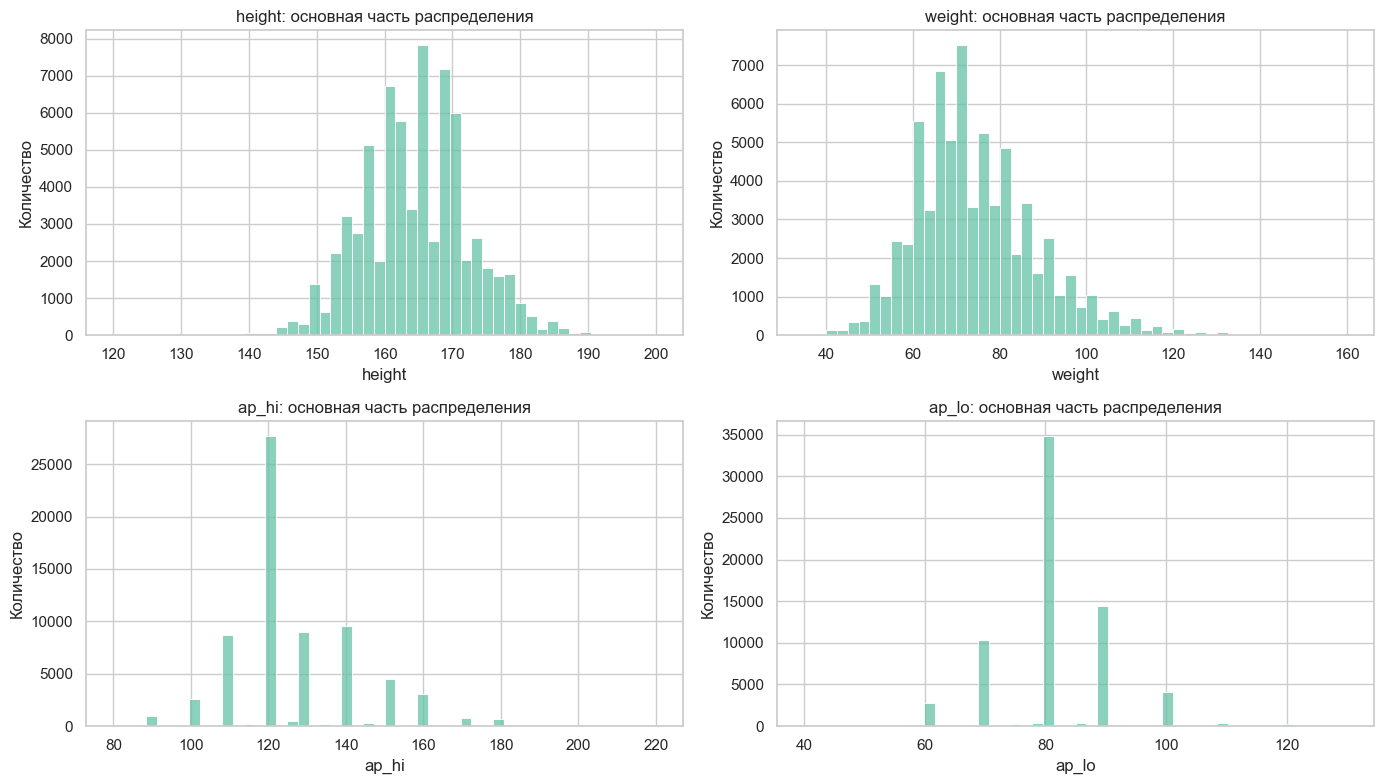

In [7]:
plot_ranges = {
    "height": (120, 200),
    "weight": (35, 160),
    "ap_hi": (80, 220),
    "ap_lo": (40, 130),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (column, (lower, upper)) in zip(axes.ravel(), plot_ranges.items()):
    values = df_raw.loc[df_raw[column].between(lower, upper), column]

    sns.histplot(values, bins=50, ax=ax)

    ax.set_title(f"{column}: основная часть распределения")
    ax.set_xlabel(column)
    ax.set_ylabel("Количество")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "numeric_distributions_main_part.png", dpi=150)
plt.show()

На графиках показана основная часть распределений числовых признаков без редких экстремальных значений. Такой масштаб позволяет подробнее рассмотреть форму распределений роста, веса и давления.

По графикам видно, что рост и вес сосредоточены в реалистичных диапазонах. Значения давления имеют выраженные пики на стандартных значениях, что может быть связано с округлением при измерении или записи данных.

Границы очистки задаются отдельно ниже и используются далее для удаления явно некорректных значений.

## Правила очистки выбросов

На основе анализа распределений зададим предметные границы очистки. Они нужны не для изменения графиков, а для удаления строк с явно некорректными значениями роста, веса и давления.


In [8]:
cleaning_limits = CLEANING_LIMITS

cleaning_limits_table = pd.DataFrame(
    [
        {"feature": feature, "lower_limit": limits[0], "upper_limit": limits[1]}
        for feature, limits in cleaning_limits.items()
    ]
)

cleaning_limits_table


,feature,lower_limit,upper_limit
0,height,120,220
1,weight,35,250
2,ap_hi,80,250
3,ap_lo,40,150


Далее посчитаем, сколько строк затрагивает каждое правило очистки.


In [9]:
outlier_checks = pd.DataFrame(
    [
        {
            "rule": "height < 120 or height > 220",
            "reason": "нереалистичный рост для взрослого пациента",
            "rows": (~df_raw["height"].between(*cleaning_limits["height"])).sum(),
        },
        {
            "rule": "weight < 35 or weight > 250",
            "reason": "нереалистичный или крайне подозрительный вес",
            "rows": (~df_raw["weight"].between(*cleaning_limits["weight"])).sum(),
        },
        {
            "rule": "ap_hi < 80 or ap_hi > 250",
            "reason": "слишком низкое или слишком высокое верхнее давление",
            "rows": (~df_raw["ap_hi"].between(*cleaning_limits["ap_hi"])).sum(),
        },
        {
            "rule": "ap_lo < 40 or ap_lo > 150",
            "reason": "слишком низкое или слишком высокое нижнее давление",
            "rows": (~df_raw["ap_lo"].between(*cleaning_limits["ap_lo"])).sum(),
        },
        {
            "rule": "ap_hi <= ap_lo",
            "reason": "верхнее давление должно быть больше нижнего",
            "rows": (df_raw["ap_hi"] <= df_raw["ap_lo"]).sum(),
        },
    ]
)

outlier_checks


,rule,reason,rows
0,height < 120 or height > 220,нереалистичный рост для взрослого пациента,53
1,weight < 35 or weight > 250,нереалистичный или крайне подозрительный вес,20
2,ap_hi < 80 or ap_hi > 250,слишком низкое или слишком высокое верхнее дав...,247
3,ap_lo < 40 or ap_lo > 150,слишком низкое или слишком высокое нижнее давл...,1034
4,ap_hi <= ap_lo,верхнее давление должно быть больше нижнего,1236


По таблице видно, что больше всего строк связано с некорректными значениями артериального давления. Особенно часто встречается нарушение условия `ap_hi > ap_lo`, когда верхнее давление оказалось меньше или равно нижнему. Это противоречит смыслу признаков и такие строки нужно удалить.

Среди отдельных признаков больше всего подозрительных значений связано с нижним давлением `ap_lo`. Для верхнего давления `ap_hi` таких строк меньше, а для роста и веса некорректных значений значительно меньше.

Эти количества нельзя складывать напрямую, потому что правила могут пересекаться: одна и та же строка может нарушать несколько условий одновременно. Поэтому итоговое число удалённых строк определяется общей маской очистки.

In [10]:
outlier_mask = (
    (~df_raw["height"].between(*cleaning_limits["height"]))
    | (~df_raw["weight"].between(*cleaning_limits["weight"]))
    | (~df_raw["ap_hi"].between(*cleaning_limits["ap_hi"]))
    | (~df_raw["ap_lo"].between(*cleaning_limits["ap_lo"]))
    | (df_raw["ap_hi"] <= df_raw["ap_lo"])
)

df_raw.loc[outlier_mask, ["id", "age", "height", "weight", "ap_hi", "ap_lo", "cardio"]].head(10)


,id,age,height,weight,ap_hi,ap_lo,cardio
224,309,21800,76,55.0,120,80,0
228,314,17489,183,98.0,160,1100,1
241,334,21932,157,60.0,160,1000,1
260,357,18217,150,83.0,140,800,1
329,458,23407,176,63.0,160,1000,1
345,482,18704,154,81.0,140,1000,1
418,594,16658,157,72.0,150,30,1
473,680,15226,150,95.0,150,1033,1
474,681,19099,156,65.0,120,150,0
559,805,20430,173,101.0,200,1000,1


В таблице приведены примеры строк, которые попадают под правила очистки. В них встречаются значения, некорректные с предметной точки зрения: слишком маленький рост, завышенное или заниженное нижнее давление, а также случаи, когда верхнее давление меньше или равно нижнему.

Такие наблюдения могут исказить распределения признаков и повлиять на обучение моделей, поэтому далее они будут удалены по общей маске очистки.

Дополнительно построим boxplot-графики для основной части числовых признаков. Они помогут компактно оценить медиану, разброс значений и наличие асимметрии без влияния экстремальных выбросов.

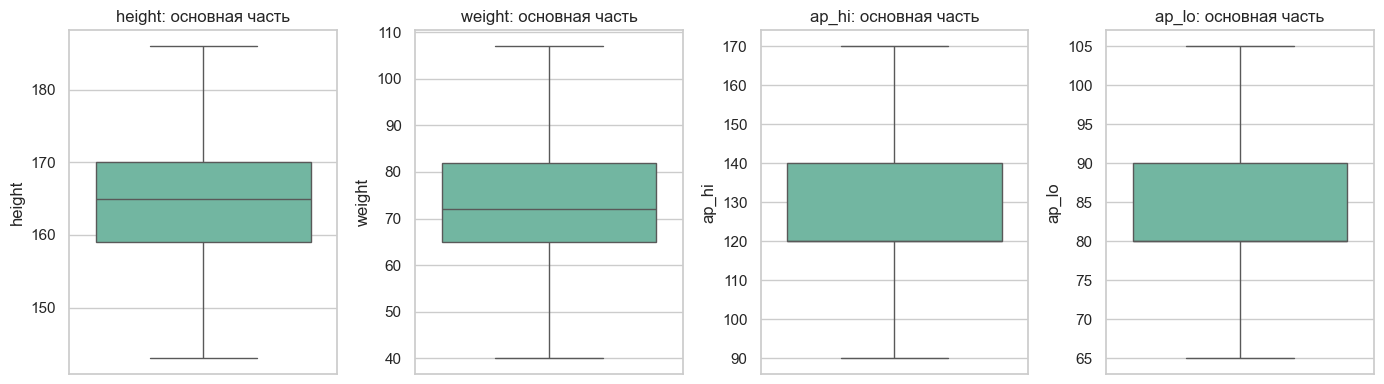

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, (column, (lower, upper)) in zip(axes, plot_ranges.items()):
    values = df_raw.loc[df_raw[column].between(lower, upper), column]
    sns.boxplot(y=values, ax=ax, showfliers=False)
    ax.set_title(f"{column}: основная часть")
    ax.set_ylabel(column)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "numeric_boxplots_main_range.png", dpi=150)
plt.show()


## Очистка данных

Теперь применим правила очистки данных и посмотрим, сколько строк осталось после удаления некорректных значений.

In [12]:
df_clean = clean_data(df_raw)

cleaning_summary = pd.DataFrame(
    {
        "stage": ["raw", "cleaned"],
        "rows": [len(df_raw), len(df_clean)],
        "columns": [df_raw.shape[1], df_clean.shape[1]],
    }
)

cleaning_summary

,stage,rows,columns
0,raw,70000,13
1,cleaned,68594,13


После очистки количество строк немного уменьшается, так как из датасета удаляются наблюдения с некорректными значениями роста, веса или артериального давления.


## Визуализации после очистки

Далее проверяется баланс классов и анализируется связь признаков с `cardio`. Эти графики не доказывают причинно-следственную связь, но позволят увидеть первичные зависимости и определить признаки, которые потенциально могут быть полезны для модели.

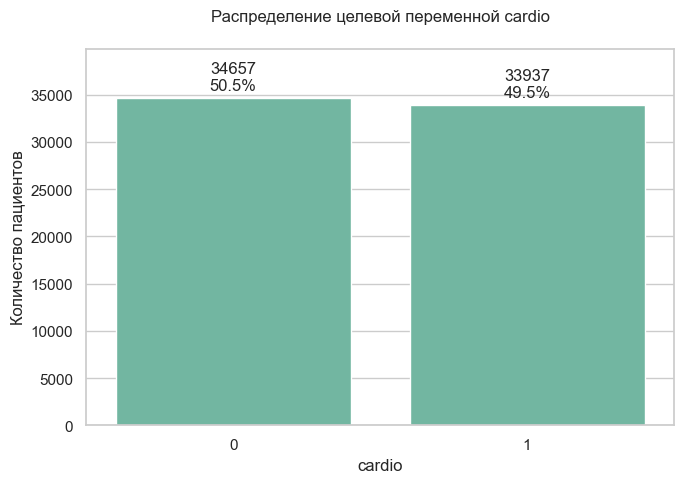

In [13]:
target_counts = df_clean["cardio"].value_counts().sort_index()
target_percent = target_counts / target_counts.sum() * 100

fig, ax = plt.subplots(figsize=(7, 5))

sns.barplot(
    x=target_counts.index.astype(str),
    y=target_counts.values,
    ax=ax,
)

ax.set_title("Распределение целевой переменной cardio", pad=20)
ax.set_xlabel("cardio")
ax.set_ylabel("Количество пациентов")

for index, value in enumerate(target_counts.values):
    percent = target_percent.iloc[index]
    ax.text(
        index,
        value + 500,
        f"{value}\n{percent:.1f}%",
        ha="center",
        va="bottom",
    )

ax.set_ylim(0, target_counts.max() * 1.15)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=150)
plt.show()

По распределению целевой переменной видно, что классы почти сбалансированы: доли классов `0` и `1` близки друг к другу.

Поэтому `accuracy` можно использовать как дополнительную метрику, но основной акцент при оценке моделей лучше делать на `ROC-AUC`, `F1`, `precision` и `recall`, чтобы учитывать не только количество правильных ответов, но и качество разделения классов.

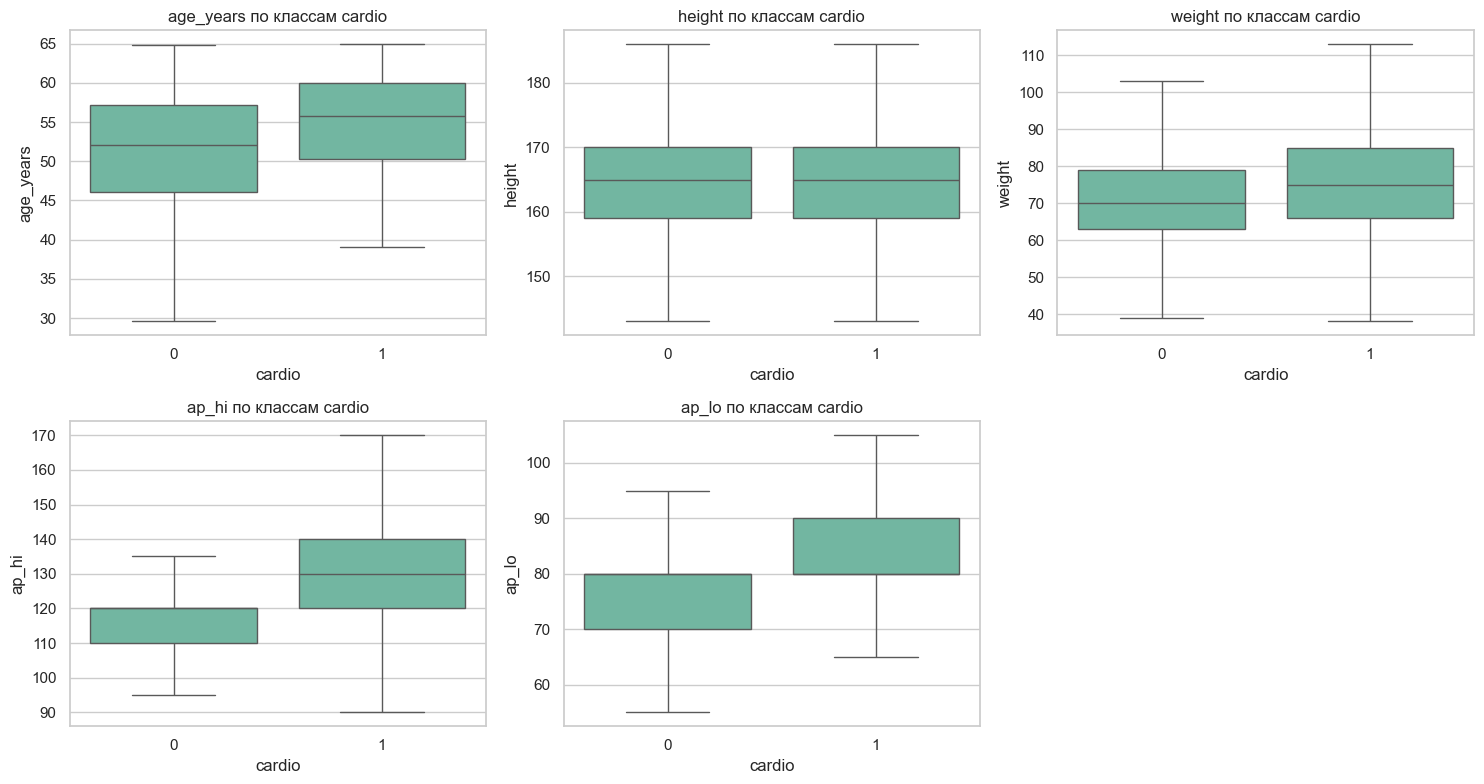

In [14]:
df_clean_plot = df_clean.assign(age_years=df_clean["age"] / 365.25)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

numeric_by_target_columns = ["age_years", "height", "weight", "ap_hi", "ap_lo"]

for ax, column in zip(axes.ravel(), numeric_by_target_columns):
    sns.boxplot(data=df_clean_plot, x="cardio", y=column, ax=ax, showfliers=False)
    ax.set_title(f"{column} по классам cardio")
    ax.set_xlabel("cardio")
    ax.set_ylabel(column)

axes.ravel()[-1].axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "numeric_features_by_target_boxplots.png", dpi=150)
plt.show()


Для числовых признаков используются boxplot-графики, так как они компактно показывают медиану, разброс и различия между классами.

По графикам видно, что у пациентов с `cardio = 1` медианный возраст выше, чем у пациентов с `cardio = 0`. Также для класса `cardio = 1` заметно выше значения верхнего и нижнего артериального давления. Это ожидаемо, так как возраст и давление напрямую связаны с риском сердечно-сосудистых заболеваний.

Различия по росту выражены слабо. По весу у класса `cardio = 1` медиана немного выше, но различие не такое явное, как для возраста и давления.

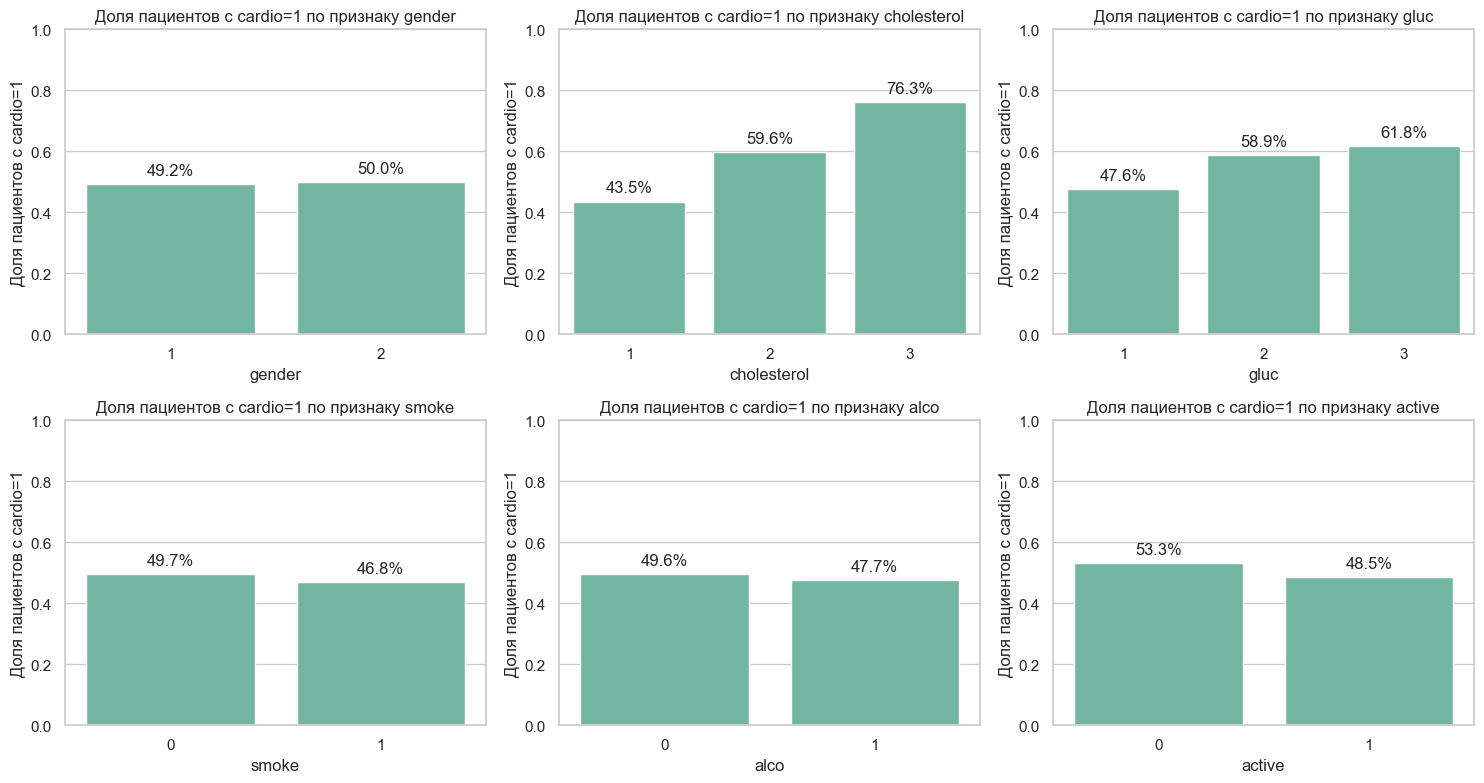

In [15]:
categorical_columns = ["gender", "cholesterol", "gluc", "smoke", "alco", "active"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, column in zip(axes.ravel(), categorical_columns):
    category_rate = (
        df_clean
        .groupby(column, observed=True)["cardio"]
        .mean()
        .sort_index()
    )

    sns.barplot(
        x=category_rate.index.astype(str),
        y=category_rate.values,
        errorbar=None,
        ax=ax,
    )

    ax.set_title(f"Доля пациентов с cardio=1 по признаку {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Доля пациентов с cardio=1")
    ax.set_ylim(0, 1)

    for index, value in enumerate(category_rate.values):
        ax.text(
            index,
            value + 0.02,
            f"{value:.1%}",
            ha="center",
            va="bottom",
        )

plt.tight_layout()
plt.savefig(FIGURES_DIR / "categorical_cardio_rate.png", dpi=150)
plt.show()

По категориальным признакам сильнее всего выделяется `cholesterol`: при более высоком уровне холестерина доля пациентов с `cardio = 1` заметно увеличивается.

Для `gluc` также видно увеличение доли `cardio = 1` при повышенных значениях, но различие выражено слабее, чем для `cholesterol`.

По признакам `gender`, `smoke`, `alco` и `active` различия между категориями небольшие. Поэтому на этапе EDA наиболее заметная связь с целевой переменной наблюдается у `cholesterol`, а также частично у `gluc`.

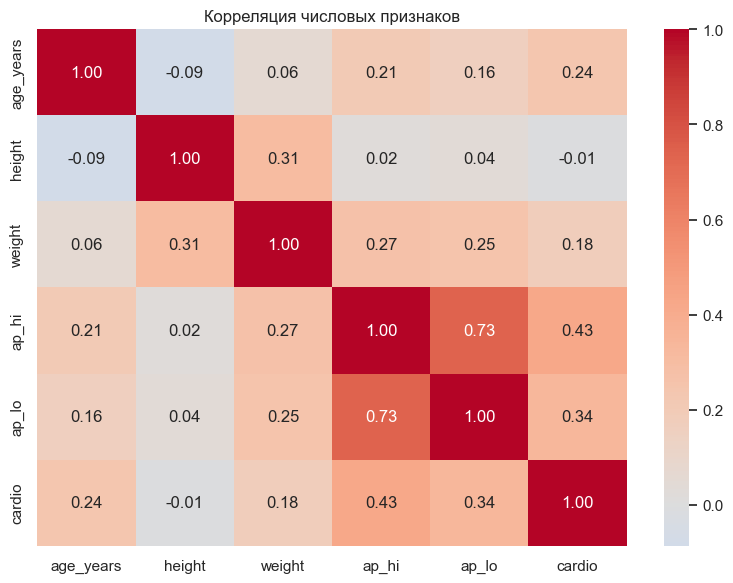

In [16]:
plt.figure(figsize=(8, 6))

corr_columns = [
    "age_years",
    "height",
    "weight",
    "ap_hi",
    "ap_lo",
    "cardio",
]

sns.heatmap(df_clean_plot[corr_columns].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Корреляция числовых признаков")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=150)
plt.show()


Корреляционная матрица показывает первичные линейные связи между числовыми признаками и целевой переменной. С `cardio` сильнее всего связаны показатели артериального давления: `ap_hi` имеет корреляцию около 0.43, `ap_lo` — около 0.34. Также заметна слабая положительная связь с возрастом: корреляция `age_years` с `cardio` составляет около 0.24.

Связь веса с целевой переменной слабее: корреляция около 0.18. Рост почти не связан с `cardio`, так как его корреляция близка к нулю.

Также видно, что `ap_hi` и `ap_lo` сильно связаны между собой: корреляция около 0.73. Это ожидаемо, поскольку оба признака описывают артериальное давление.

## Train / Validation / Test Split

Далее данные разделяются на три части: `train`, `validation` и `test` в пропорции 70/15/15. Разделение выполняется со стратификацией по целевой переменной `cardio`, чтобы во всех выборках сохранить примерно одинаковое соотношение классов.

Очистка данных выше выполняется только по предметным правилам и не опирается на значение `cardio`, поэтому целевая переменная не влияет на подготовку признаков.

Все дальнейшие преобразования признаков, например масштабирование числовых признаков и кодирование категориальных, должны настраиваться только на `train` внутри pipeline. Выборка `validation` используется для выбора модели и настройки гиперпараметров, а `test` остаётся независимой выборкой для финальной оценки качества.

In [17]:
x, y = split_features_target(df_clean)
x_train, x_val, x_test, y_train, y_val, y_test = make_train_val_test_split(x, y)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "rows": [len(x_train), len(x_val), len(x_test)],
        "target_rate": [y_train.mean(), y_val.mean(), y_test.mean()],
    }
)

split_summary


,split,rows,target_rate
0,train,48015,0.494762
1,validation,10289,0.494703
2,test,10290,0.494752


По таблице видно, что после разбиения доля положительного класса `cardio = 1` почти одинаковая во всех выборках: около 49.5% в `train`, `validation` и `test`.

Это подтверждает, что стратификация выполнена корректно: выборки не отличаются по базовому распределению целевой переменной, поэтому `validation` и `test` можно использовать для честной оценки качества моделей.

Разбиение на `train`, `validation` и `test` здесь выполняется для проверки корректности схемы split и сохранения распределения целевой переменной. В следующих ноутбуках это же разбиение будет воспроизводиться через общую функцию `make_train_val_test_split()` с фиксированным `random_state`.

## Метрики качества

Решается задача бинарной классификации: модель должна определить, есть ли у пациента сердечно-сосудистое заболевание.

В качестве основной метрики будет использоваться **ROC-AUC**. Эта метрика показывает, насколько хорошо модель разделяет классы по предсказанным вероятностям, и не зависит от выбранного порога классификации. Поэтому она удобна для сравнения разных моделей.

Дополнительно будут анализироваться **recall**, **precision** и **F1-score**. Для медицинской задачи особенно важен **recall** по классу `cardio = 1`, потому что пропуск пациента с заболеванием может быть опаснее ложного срабатывания.

**Accuracy** можно использовать как дополнительную метрику, так как классы в датасете почти сбалансированы. Однако её недостаточно как единственного критерия качества, потому что она не показывает отдельно качество поиска пациентов с заболеванием.

## Сохранение подготовленных данных

После очистки подготовленный датасет сохраняется в папку `data/processed`. На следующих этапах обучения моделей будет использоваться именно эта версия данных.

In [18]:
save_processed_data(df_clean, PROCESSED_DATA_PATH)
PROCESSED_DATA_PATH


PosixPath('/Users/iordanovpavel/Desktop/hseml-group-project-iordanov05/data/processed/cardio_clean.csv')